# Transmon Leakage

In [9]:
using Piccolo
using SparseArrays
using Random; Random.seed!(123)
using CairoMakie
using LinearAlgebra
using Optim

In [ ]:
import Pkg
 #Pkg.gc()
Pkg.develop(path="/Users/jettajb1/Work/DiffEQ/HarmonicSolvers/")


In [5]:
using HarmonicSolvers

In [ ]:
const T0 = 10.0    
const N  = 50       
const dt = T0 / N
#const times = collect(range(0, T0, length = N))

const LEVELS = 3
const DELTA  = -0.4    #2.51327412 #ghz
const U_BOUND = [0.2, 0.2]
const DDU_BOUND = 1.0

sys = TransmonSystem(levels = 3, δ = DELTA, drive_bounds = [0.5, 0.5], multiply_by_2π = false)
U_goal = EmbeddedOperator(:X, sys)

EmbeddedOperator{ComplexF64}(ComplexF64[0.0 + 0.0im 1.0 + 0.0im 0.0 + 0.0im; 1.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im], [1, 2], [3])

## 1. Baseline leakage 

In [31]:
const super_duper_value = 0.598144006661 # integral from -1/2 to 1/2 of e^(-8u^2)
λ = √2
Δ = - 2π * 400 / 1000

function gaussian_curve(T, N)
    A = π / (T * (super_duper_value - ℯ^(-2))) / 2
    μ = T / 2
    σ = T / 4

    times = collect(range(0, T, length = N))
    
    function f(t)
        return A * (ℯ^(-(t - μ)^2 / (2σ^2)) - ℯ^(-2))
    end

    function f_prime(t)
        return A * ℯ^(-(t - μ)^2 / (2σ^2)) * ((μ - t)/σ^2)
    end

    println(sum((f.(times[1:end-1]) + f.(times[2:end]))/2) * T / N)
    println(f(times[1]))
    println(f(times[end]))

    E_π = f.(times)
    Ė_π = f_prime.(times)
    return times, E_π, Ė_π
end

function drag_gaussian(T, N)
    times, E_π, Ė_π = gaussian_curve(T, N)
    E_x = E_π .+ ((λ^2-4)/(8Δ^2) * E_π .^ 3) - ((13λ^4 - 76λ^2 + 112) / 128Δ^4 * E_π .^ 5)
    E_y = -Ė_π ./ Δ + ((33(λ^2-2)/24Δ^3) * E_π .^2 .* Ė_π)
    return times, E_x, E_y
end

drag_gaussian (generic function with 1 method)

In [47]:
controls = zeros(2, N)
times, gaussian, _ = gaussian_curve(T0, N)
controls[1, :] .= gaussian
pulse = ZeroOrderPulse(controls, times)


#println(1 - fidelity(out))

1.539130449925284
0.0
0.0


ErrorException: invalid assignment to constant Main.times. This redefinition may be permitted using the `const` keyword.

In [35]:
traj = UnitaryTrajectory(sys, pulse, U_goal)
out = rollout(traj)

UnitaryTrajectory
  system: 3-level QuantumSystem
  drives: ZeroOrderPulse with 2 drives
  duration: 10.0

In [ ]:
qcp = SmoothPulseProblem(traj,N)

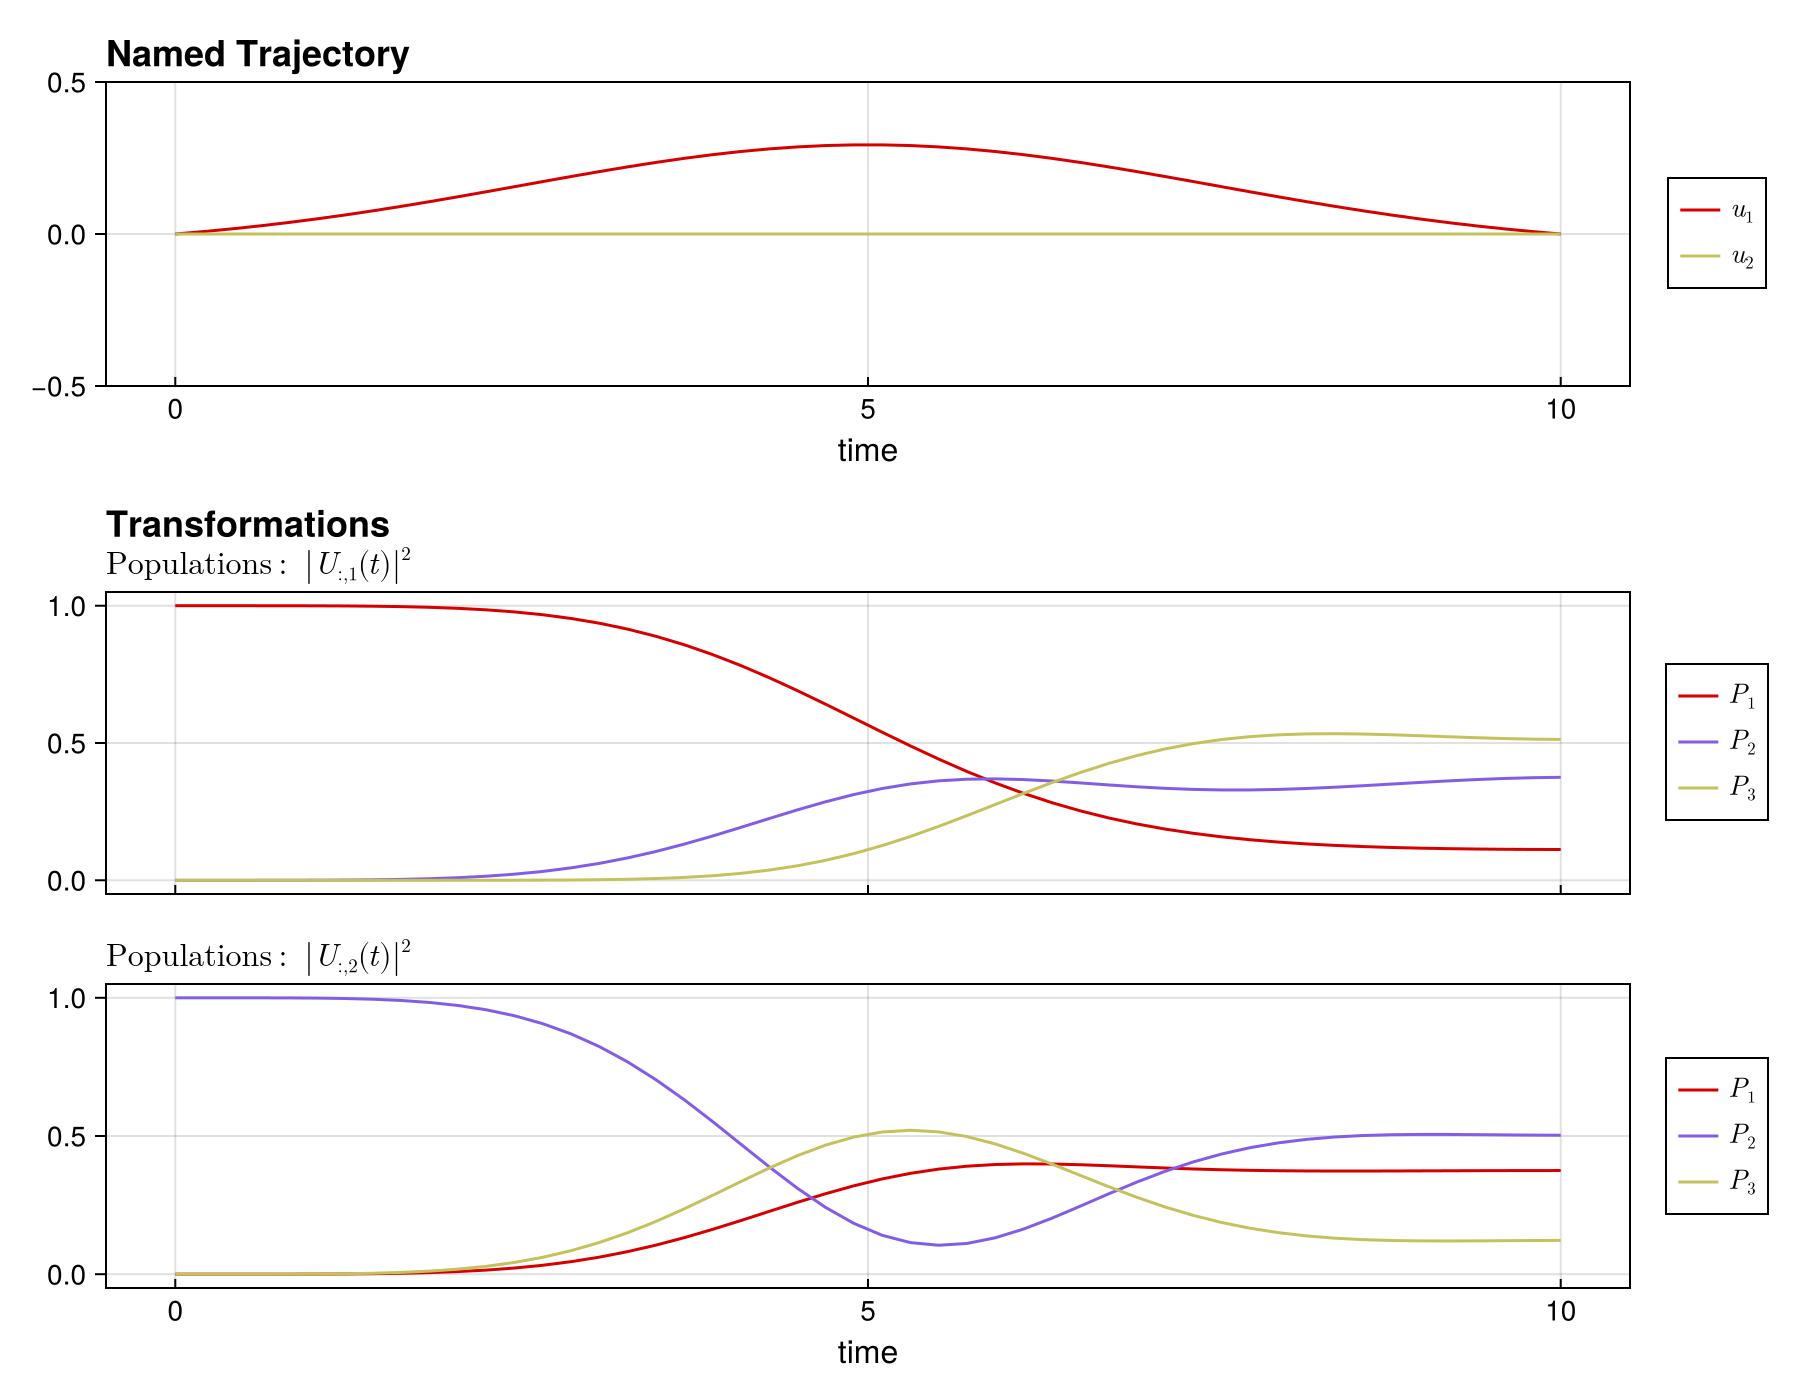

In [42]:
fig_naive = plot_unitary_populations(get_trajectory(qcp); fig_size = (900, 700))

In [46]:
controls = zeros(2, N)
times, controls[1, :], controls[2, :] = drag_gaussian(T0, N)

pulse = ZeroOrderPulse(controls, times)
traj = UnitaryTrajectory(sys, pulse, U_goal)
out = rollout(traj)
qcp = SmoothPulseProblem(traj, N)

plot_unitary_populations(get_trajectory(qcp))

1.539130449925284
0.0
0.0


ErrorException: invalid assignment to constant Main.times. This redefinition may be permitted using the `const` keyword.

In [10]:
function final_leakage_population(qcp, sys)
    qtraj = get_trajectory(qcp)
    named_traj = NamedTrajectory(qtraj, N)

    fid = unitary_rollout_fidelity(qtraj, named_traj, sys)

    pulse_opt = extract_pulse(qtraj, named_traj)

    qtraj_opt = rollout(UnitaryTrajectory(sys, pulse_opt, EmbeddedOperator(:X, sys)))

    T_final = named_traj.t[end]
    U_final = qtraj_opt(T_final)

    leak = abs2(U_final[3, 1])

    return fid, leak
end

final_leakage_population (generic function with 1 method)

## 2. Traditional DRAG


In [11]:

const DRAG_SIGMA = T0 / 6
const DRAG_AMP   = pi/ (DRAG_SIGMA*sqrt(2*pi)) 

I(t)  = DRAG_AMP * exp(-(t - T0/2)^2 / (2 * DRAG_SIGMA^2))
dI(t) = -((t - T0/2) / DRAG_SIGMA^2) * I(t)  

Q(t)  = -dI(t) / DELTA

drag_control(t) = [I(t), Q(t)]

drag_control (generic function with 1 method)

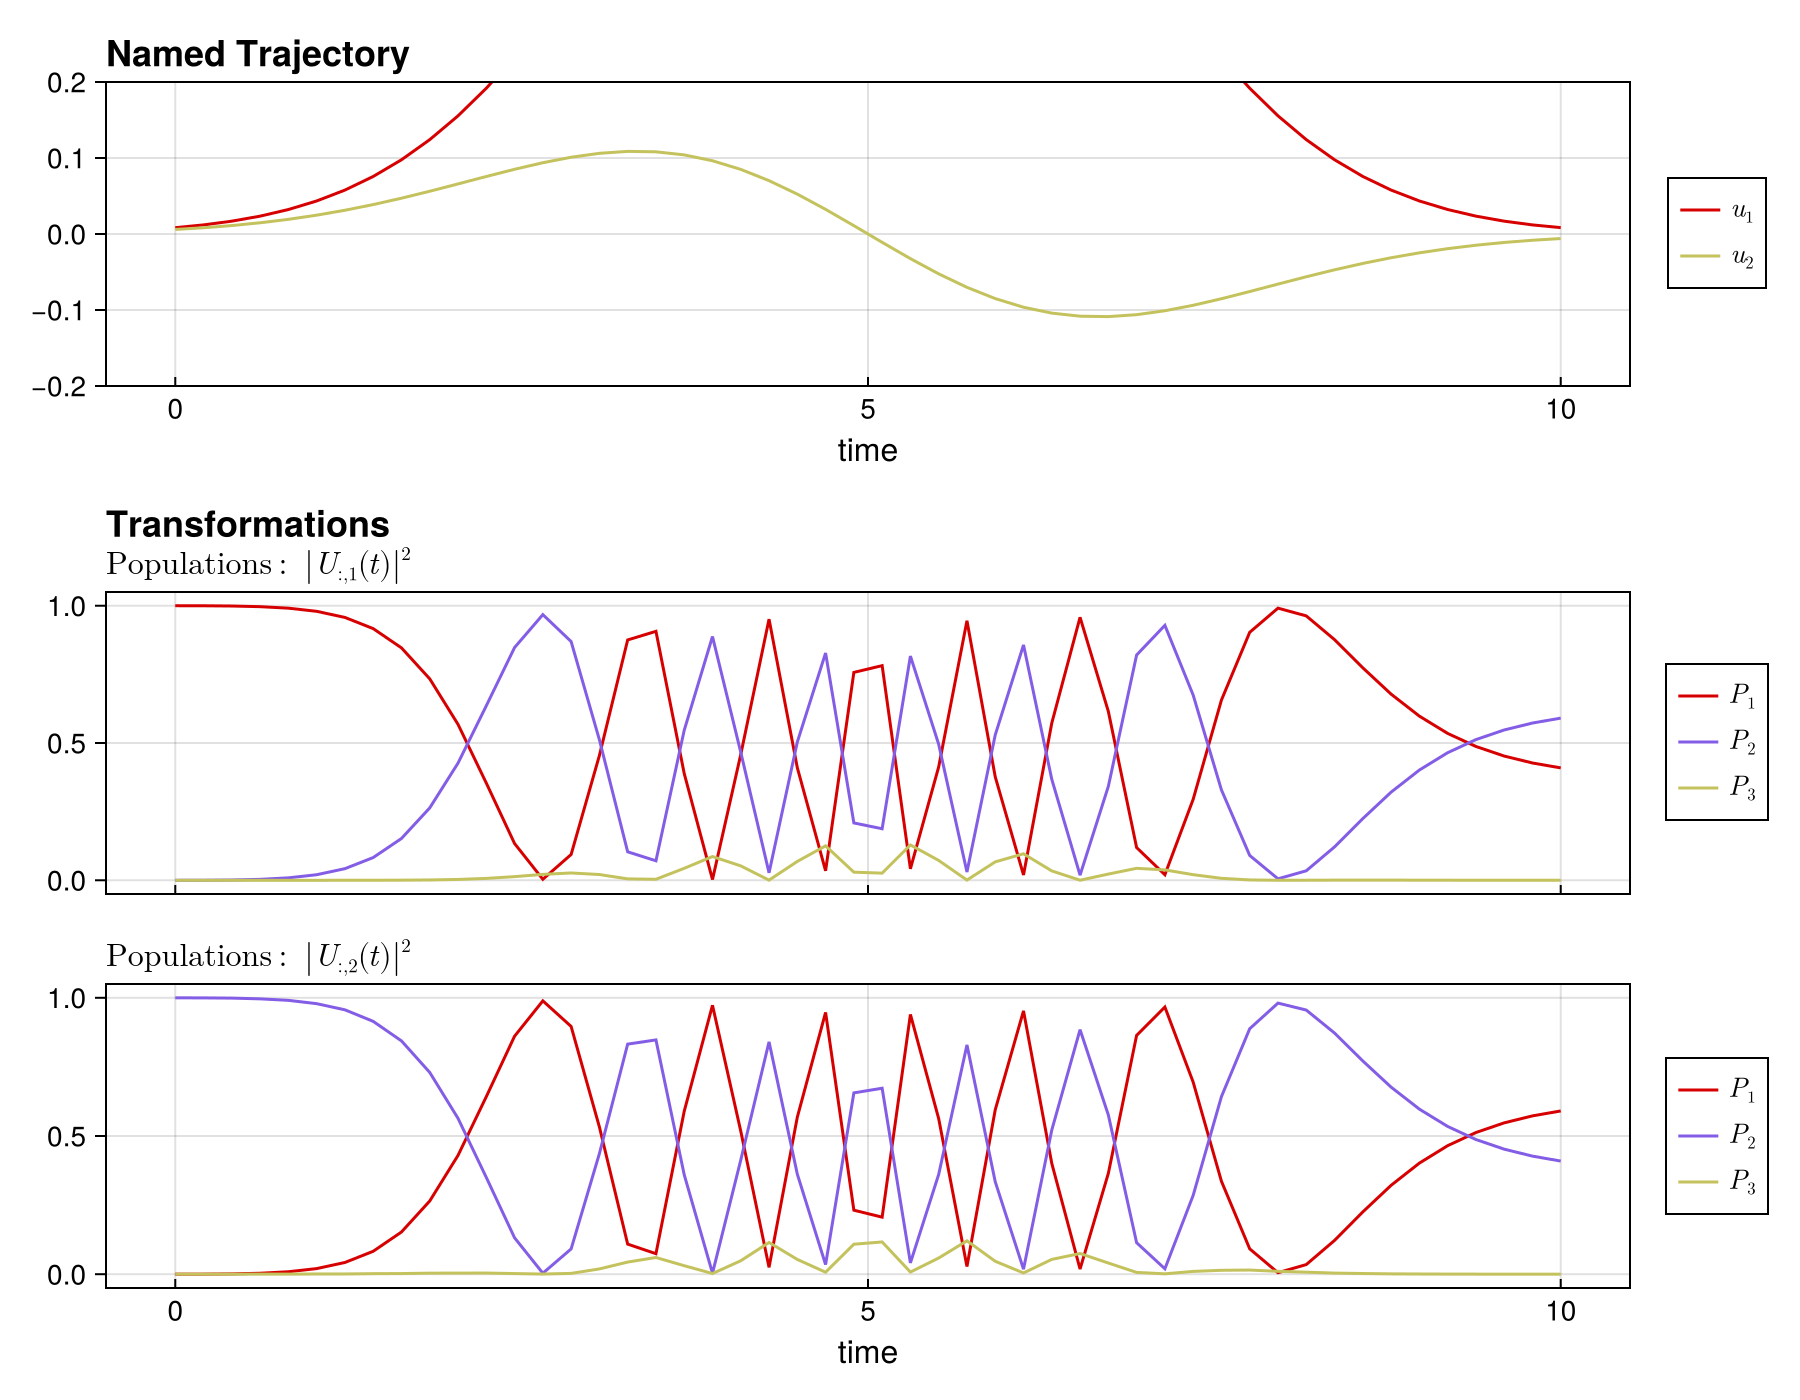

In [12]:

plot_t_grid = collect(range(0, T0, length = N))

pulse_drag = try
    FunctionPulse(drag_control, T0, 2)
catch e
    @warn "FunctionPulse constructor flaied using ZeroOrderPulse" exception=e
    dense_controls = reduce(hcat, drag_control.(plot_t_grid))
    ZeroOrderPulse(dense_controls, plot_t_grid)
end
qtraj_drag = UnitaryTrajectory(sys, pulse_drag, op)


# fddscretize the pulse manually into a discrete structure for plotting
dense_controls = reduce(hcat, drag_control.(plot_t_grid))
plot_pulse_discrete = ZeroOrderPulse(dense_controls, plot_t_grid)
plot_qtraj_discrete = UnitaryTrajectory(sys, plot_pulse_discrete, op)


named_traj_drag = NamedTrajectory(plot_qtraj_discrete, N)

fig_drag = plot_unitary_populations(named_traj_drag; fig_size = (900, 700))


In [28]:
fid_drag = fidelity(qtraj_drag)
U_drag_final = qtraj_drag(T0)
leak_drag = abs2(U_drag_final[3, 1])

println("DRAG: fidelity = ", fid_drag, ", leakage pop = ", leak_drag)

DRAG: fidelity = 0.7277686030092987, leakage pop = 1.9163798055948836e-5


## 3. GRAPE (Optim.jl + HarmonicSolvers)


In [14]:
using LinearAlgebra
a = zeros(ComplexF64, LEVELS, LEVELS)
for k in 1:(LEVELS - 1)
    a[k, k+1] = sqrt(k)
end

n_op = a' * a

H_drift = (DELTA / 2) * (n_op * (n_op - LinearAlgebra.I) )  # anharmonicity delta/2 * n(n-1)
H_I = a + a'
H_Q = 1im * (a - a')

ψ0_t = ComplexF64[1.0, 0.0, 0.0]
ψtarget_t = ComplexF64[0.0, 1.0, 0.0]

rk4_solver = HarmonicSolvers.RungeKutta4()
LEAK_WEIGHT = 5.0   

5.0

In [15]:
using DifferentialEquations

function schrodinger_transmon_native!(dψ, ψ, p, t)
    Hd, HI, HQ, uI_vals, uQ_vals, dt_ = p

    idx = clamp(floor(Int, t / dt_) + 1, 1, length(uI_vals))

    H = Hd + uI_vals[idx] * HI + uQ_vals[idx] * HQ

    mul!(dψ, H, ψ, -1im, 0)
    return nothing
end

function run_transmon(uI_vals, uQ_vals)
    params = (H_drift, H_I, H_Q, uI_vals, uQ_vals, dt)
    prob = ODEProblem(schrodinger_transmon_native!, ψ0_t, (0.0, T0), params)
    
    sol = solve(prob, Tsit5(); tstops=collect(0:dt:T0), abstol=1e-8, reltol=1e-8)
    return sol
end


function grape_objective(uI_vals, uQ_vals)
    sol = run_transmon(uI_vals, uQ_vals)
    ψ_final = sol.u[end]
    fid = abs2(dot(ψtarget_t, ψ_final))
    leak = abs2(ψ_final[3])
    return (1.0 - fid) + LEAK_WEIGHT * leak
end

grape_objective (generic function with 1 method)

In [35]:

function objective_raw(controls_flat)
    uI_vals = controls_flat[1:N]
    uQ_vals = controls_flat[N+1:2N]
    return grape_objective(uI_vals, uQ_vals)
end

init_raw = 0.1 * randn(2N)
result_raw = optimize(objective_raw, init_raw, LBFGS(), #maybe LBFGS or Newton method f
                       Optim.Options(iterations = 200))
best_raw = Optim.minimizer(result_raw)

println("Objective 1 (raw) final infidelity+leakage = ", Optim.minimum(result_raw))

Objective 1 (raw) final infidelity+leakage = 4.224213953632969e-11


In [17]:

function cosine_basis(n_modes::Int, N::Int)

    τ = collect(0:(N-1)) ./ (N - 1) 
    return [cos.(pi * j .* (τ .- 0.5)) for j in 0:(n_modes - 1)]
end


function expand_control(coefficients, basis)
    return sum(c .* b for (c, b) in zip(coefficients, basis))
end

n_modes = 4
g_basis = cosine_basis(n_modes, N)

function objective_smooth(coeffs)
    cI = coeffs[1:n_modes]
    cQ = coeffs[n_modes+1:2n_modes]
    uI_vals = expand_control(cI, g_basis)
    uQ_vals = expand_control(cQ, g_basis)
    return grape_objective(uI_vals, uQ_vals)
end

init_smooth = 0.1 * randn(2n_modes)
result_smooth = optimize(objective_smooth, init_smooth,
                          Optim.Options(iterations = 2000))
best_smooth_coeffs = Optim.minimizer(result_smooth)

println("Objective 2 (smooth basis) final infidelity+leakage = ", Optim.minimum(result_smooth))

Objective 2 (smooth basis) final infidelity+leakage = 0.0034878599648535042


### Visualizing GRAPE leakage populations



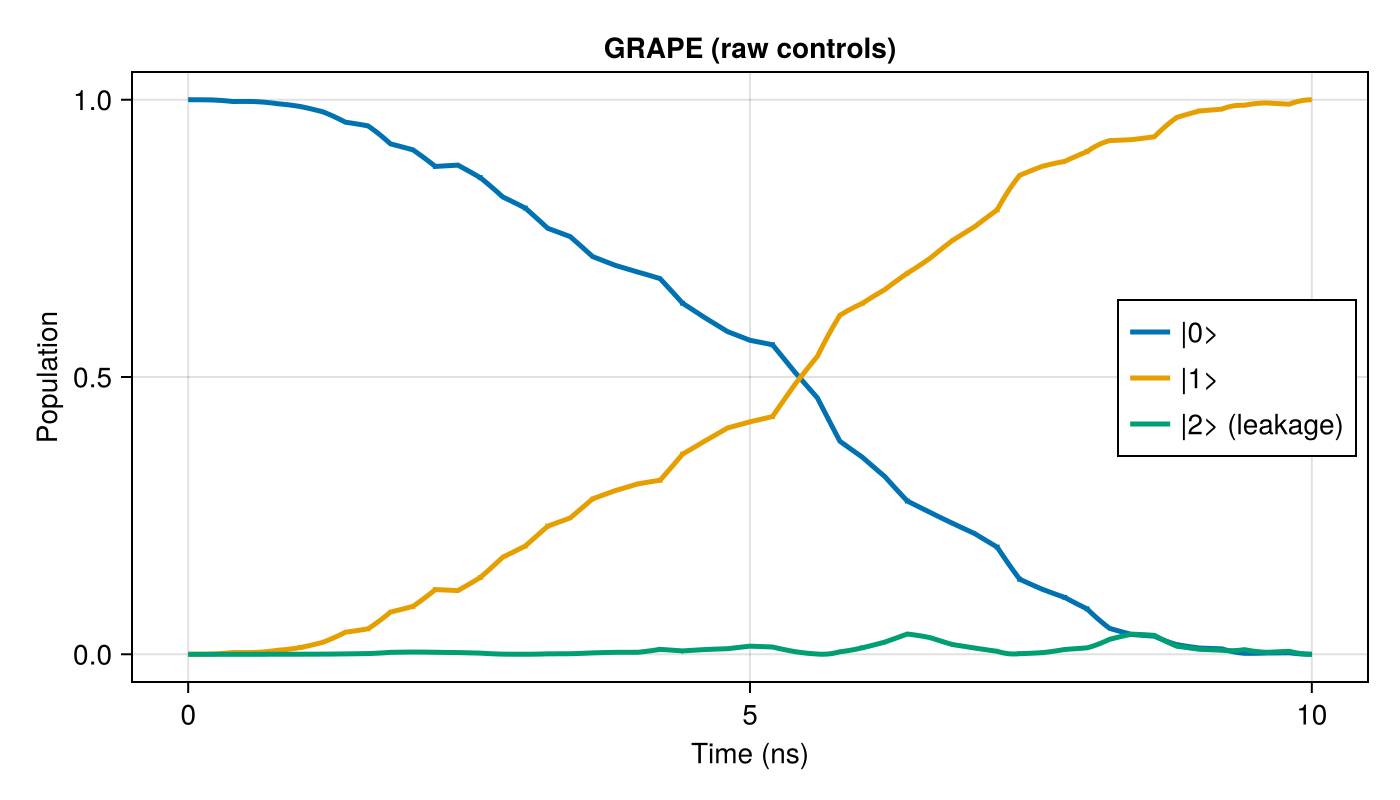

In [36]:
function population_trajectory(uI_vals, uQ_vals)
    sol = run_transmon(uI_vals, uQ_vals)
    pops = reduce(hcat, [abs2.(psi) for psi in sol.u]) 
    return sol.t, pops
end

function plot_populations(t, pops; title = "Populations")
    fig = Figure(size = (700, 400))
    ax = Axis(fig[1, 1], xlabel = "Time (ns)", ylabel = "Population", title = title)
    labels = ["|0>", "|1>", "|2> (leakage)"]
    for lvl in 1:LEVELS
        lines!(ax, t, pops[lvl, :], label = labels[lvl], linewidth = 2.5)
    end
    axislegend(ax, position = :rc)
    return fig
end

t_raw, pops_raw = population_trajectory(best_raw[1:N], best_raw[N+1:2N])
fig_grape_raw = plot_populations(t_raw, pops_raw; title = "GRAPE (raw controls)")

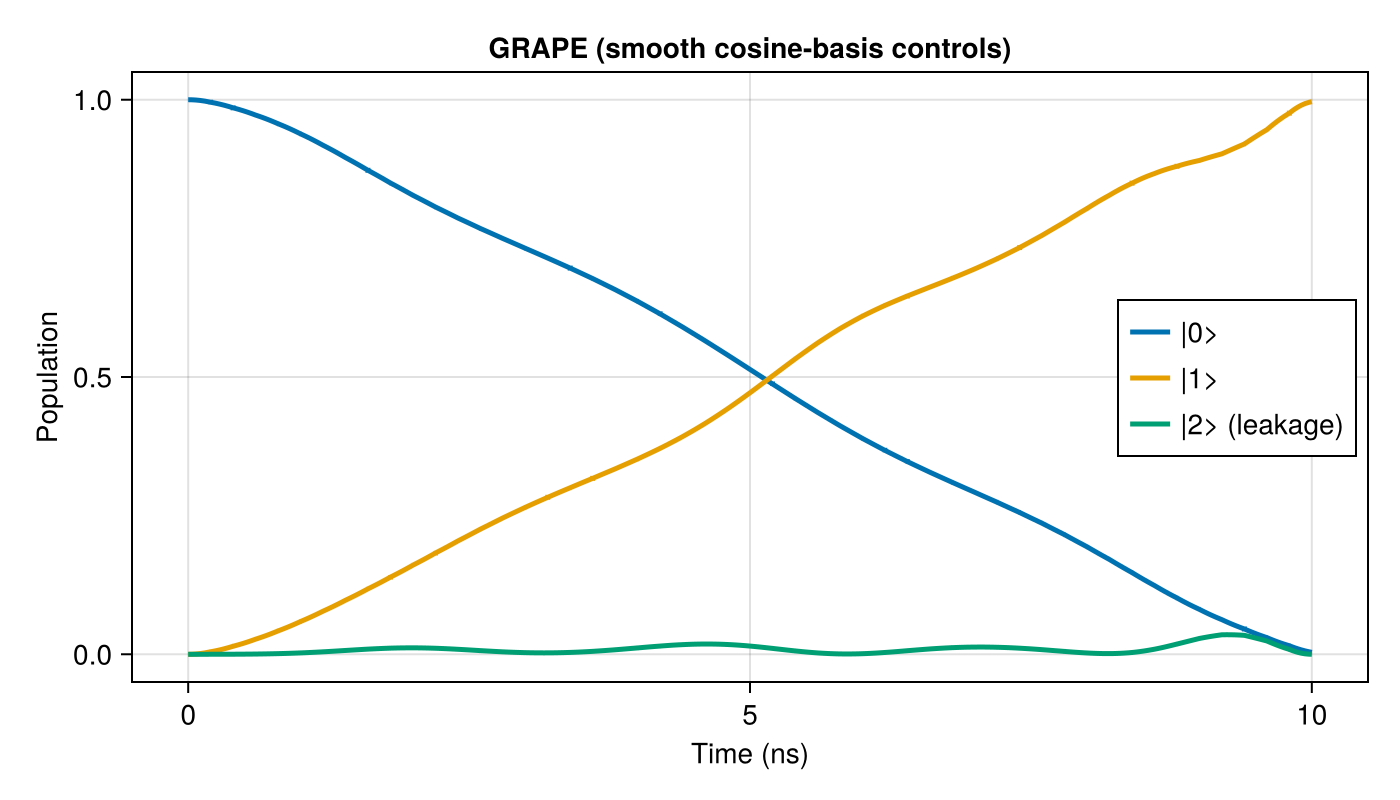

In [37]:
best_uI_smooth = expand_control(best_smooth_coeffs[1:n_modes], g_basis)
best_uQ_smooth = expand_control(best_smooth_coeffs[n_modes+1:2n_modes], g_basis)
t_smooth, pops_smooth = population_trajectory(best_uI_smooth, best_uQ_smooth)
fig_grape_smooth = plot_populations(t_smooth, pops_smooth; title = "GRAPE (smooth cosine-basis controls)")

In [38]:
ψ_final_raw = run_transmon(best_raw[1:N], best_raw[N+1:2N]).u[end]
fid_grape_raw = abs2(dot(ψtarget_t, ψ_final_raw))
leak_grape_raw = abs2(ψ_final_raw[3])

ψ_final_smooth = run_transmon(best_uI_smooth, best_uQ_smooth).u[end]
ψ_final_smooth ./= norm(ψ_final_smooth)
leak_grape_smooth = abs2(ψ_final_smooth[3])

fid_grape_smooth = min(1.0, abs2(dot(ψtarget_t, ψ_final_smooth)))


println("GRAPE (raw):    fidelity = ", fid_grape_raw, ", leakage pop = ", leak_grape_raw)
println("GRAPE (smooth): fidelity = ", fid_grape_smooth, ", leakage pop = ", leak_grape_smooth)

GRAPE (raw):    fidelity = 0.9999999999579022, leakage pop = 2.8873964337122636e-14
GRAPE (smooth): fidelity = 0.9965140174265159, leakage pop = 3.75471657720593e-7
